# 1. Dataset:

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mticker
import warnings
from IPython.display import display
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.linear_model import LinearRegression
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
import itertools
import matplotlib.ticker as ticker

warnings.filterwarnings('ignore')

# Set style for better visualizations
sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 100

In [5]:
# Load and visualize data:
print("WALMART SALES FORECAST")
print("="*80)
df = pd.read_csv("../data/Walmart.csv")

print("\n Dataset Overview")
df.info()

WALMART SALES FORECAST

 Dataset Overview
<class 'pandas.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Store         6435 non-null   int64  
 1   Date          6435 non-null   str    
 2   Weekly_Sales  6435 non-null   float64
 3   Holiday_Flag  6435 non-null   int64  
 4   Temperature   6435 non-null   float64
 5   Fuel_Price    6435 non-null   float64
 6   CPI           6435 non-null   float64
 7   Unemployment  6435 non-null   float64
dtypes: float64(5), int64(2), str(1)
memory usage: 402.3 KB


In [6]:
# Convert data
df['Date'] = pd.to_datetime(df['Date'], format='%d-%m-%Y')

# Data dimension Verification:
print("\n" + "="*80)
print("DATA DIMENSION")
print("="*80)
print(f"Total number of stores: {df['Store'].nunique()}")
print(f"Date range: {df['Date'].min().strftime('%Y-%m-%d')} to {df['Date'].max().strftime('%Y-%m-%d')}")
print(f"Total weeks: {df['Date'].nunique()}")
print(f"Total records: {len(df):,}")
print(f"Total records per store (avg): {len(df) / df['Store'].nunique():.1f}")

# Missing data check:
missing_values = df.isnull().sum()
print("\nMissing Values:")
print(missing_values[missing_values >0] if missing_values.sum() > 0 else "No missing values found!")

# Analysis constants:
TEST_SIZE = 13      # Last 13 Weeks for testing
SEASONAL_PERIOD = 13 # Quarterly seasonality 


DATA DIMENSION
Total number of stores: 45
Date range: 2010-02-05 to 2012-10-26
Total weeks: 143
Total records: 6,435
Total records per store (avg): 143.0

Missing Values:
No missing values found!


# 2. Correlation and Variance Explained by External Factors


CORRELATION ANALYSIS - External Factors Impact

Correlation with Weekly Sales:
  • Holiday_Flag        : +0.0369
  • Fuel_Price          : +0.0095
  • Temperature         : -0.0638
  • CPI                 : -0.0726
  • Unemployment        : -0.1062


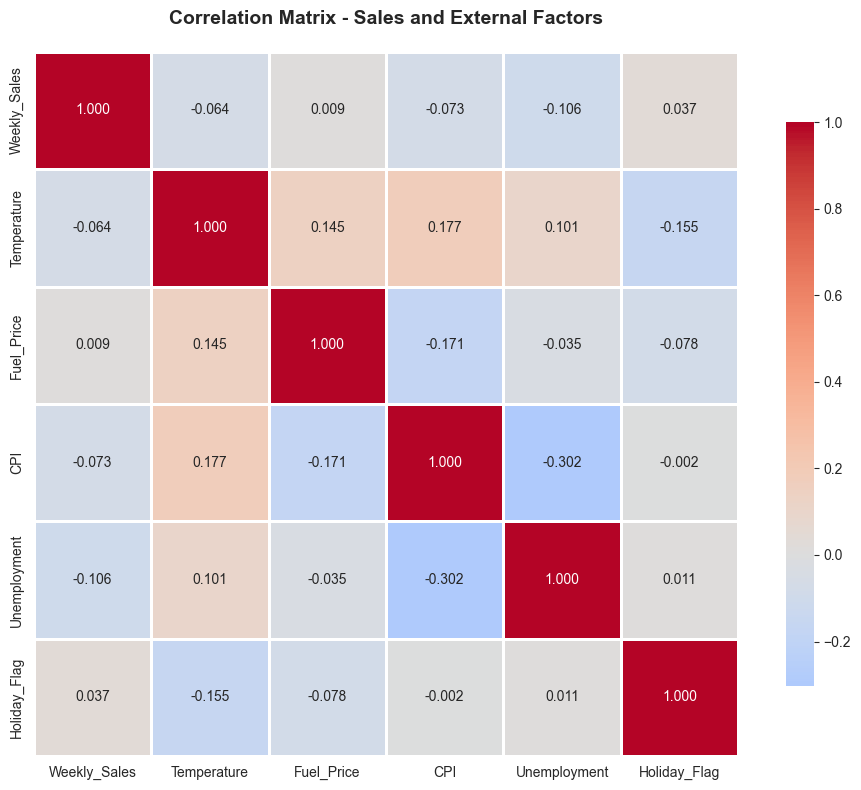

In [8]:
print("\n" + "="*80)
print("CORRELATION ANALYSIS - External Factors Impact")
print("="*80)

# Calculate correlations
correlation_features = ['Weekly_Sales', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment', 'Holiday_Flag']
correlation_df = df[correlation_features].corr()

print("\nCorrelation with Weekly Sales:")
sales_corr = correlation_df['Weekly_Sales'].sort_values(ascending=False)
for feature, corr_value in sales_corr.items():
    if feature != 'Weekly_Sales':
        print(f"  • {feature:20s}: {corr_value:+.4f}")

plt.figure(figsize=(10, 8))
sns.heatmap(
    correlation_df,
    annot=True,
    fmt='.3f',
    cmap='coolwarm',
    center=0,
    square=True,
    linewidths=1,
    cbar_kws={"shrink": 0.8}
)

plt.title('Correlation Matrix - Sales and External Factors', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

- External factors such as Fuel Price, CPI, Temperature, and Unemployment show very weak correlations with Weekly Sales. 

- Holiday_Flag has a small positive correlation, meaning sales tend to rise slightly during holiday weeks. 

- The heatmap confirms that no external variable has strong linear influence on weekly sales, suggesting that seasonality, promotions, and store-level effects likely drive most variation.

In [ ]:
print("="*80)
print("VARIANCE - External Fators Impact")
print("="*80)

# Temperature variance explanation (R-squared)
X_temp = df[['Temperature']].dropna()
y_sales = df.loc[X_temp.index, 'Weekly_Sales']

temp_model = LinearRegression()
temp_model.fit(X_temp, y_sales)
r2_temp = temp_model.score(X_temp, y_sales)

print(f"• Temperature R² Score: {r2_temp:.4f} ({r2_temp*100:.2f}% of variance explained)")

# Multiple regression with all features
X_multi = df[['Temperature', 'Fuel_Price', 'CPI', 'Unemployment', 'Holiday_Flag']].dropna()
y_multi = df.loc[X_multi.index, 'Weekly_Sales']

multi_model = LinearRegression()
multi_model.fit(X_multi, y_multi)
r2_multi = multi_model.score(X_multi, y_multi)

print(f"• All Features R2 Score: {r2_multi:.4f} ({r2_multi*100:.2f}% of variance explained)")

# Feature importance


VARIANCE - External Fators Impact
• Temperature R² Score: 0.0041 (0.41% of variance explained)
• All Features R2 Score: 0.0254 (2.54% of variance explained)
